In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  kurumsal bir tema 
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

# İndirdiğim yeni banka veri seti 
df = pd.read_csv("Bank Customer Churn Prediction.csv")

# Yeni verimizin ilk 5 satırına ve sütunlarına bir bakalım
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Veri setindeki tüm sütun isimlerini listeler
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

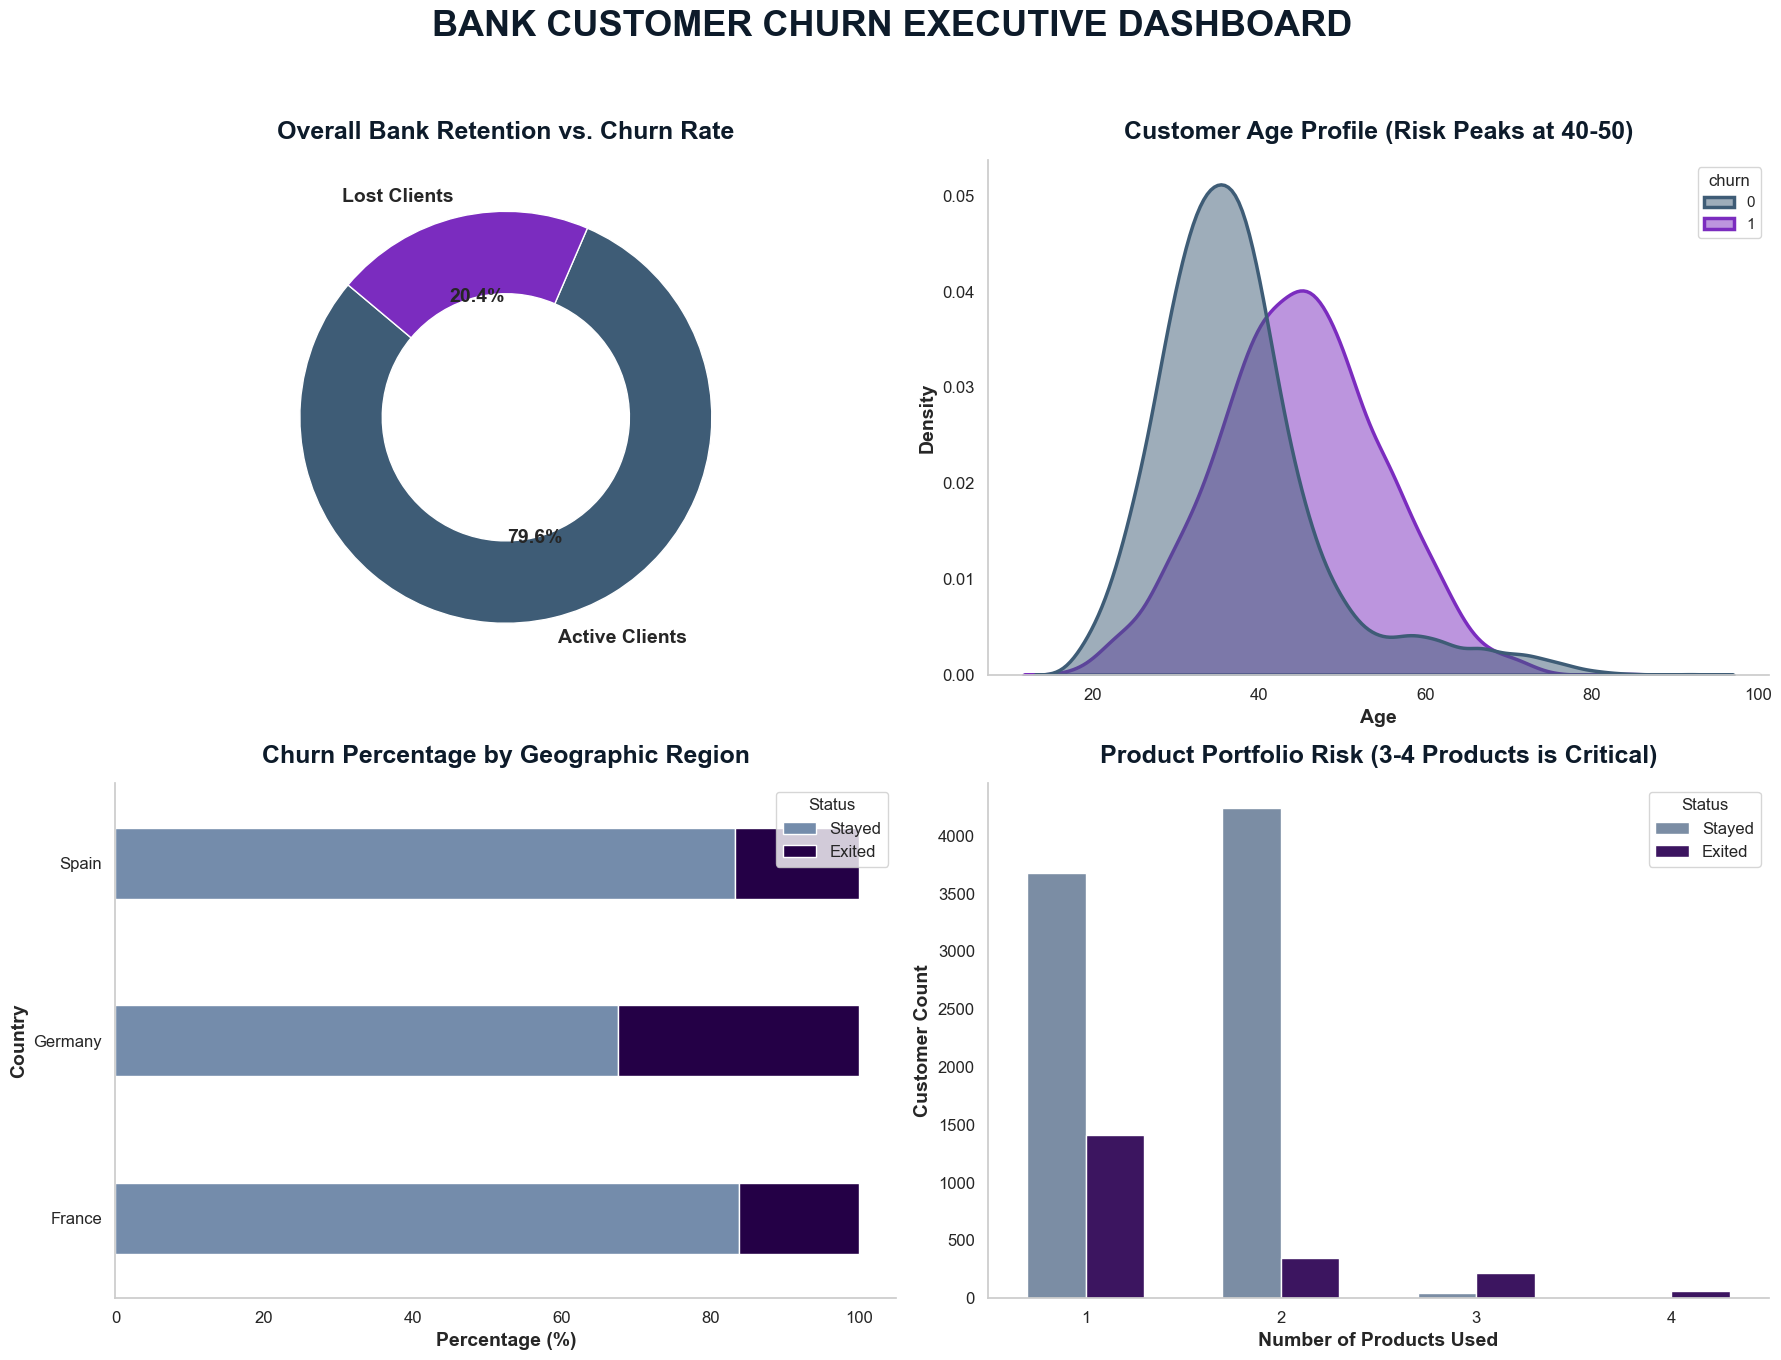

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Genel font ve stil ayarları
sns.set_theme(style="white")
plt.rcParams["font.family"] = "sans-serif"

fig, axes = plt.subplots(2, 2, figsize=(18, 14), facecolor="#ffffff")

# ANA BAŞLIK 
fig.suptitle("BANK CUSTOMER CHURN EXECUTIVE DASHBOARD", fontsize=26, fontweight="bold", color="#0d1b2a", y=0.97)

# 1. Grafik: Donut (Genel Durum)
churn_counts = df['churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=["Active Clients", "Lost Clients"], autopct='%1.1f%%', startangle=140, 
        colors=["#3e5c76", "#7b2cbf"], wedgeprops=dict(width=0.4, edgecolor='w'), textprops={'fontsize': 14, 'weight': 'bold'})
axes[0, 0].set_title("Overall Bank Retention vs. Churn Rate", fontsize=18, fontweight="bold", color="#0d1b2a", pad=15)

# 2. Grafik: Yaş Dağılımı 
sns.kdeplot(ax=axes[0, 1], data=df, x="age", hue="churn", fill=True, palette=["#3e5c76", "#7b2cbf"], alpha=0.5, common_norm=False, linewidth=2.5)
axes[0, 1].set_title("Customer Age Profile (Risk Peaks at 40-50)", fontsize=18, fontweight="bold", color="#0d1b2a", pad=15)
axes[0, 1].set_xlabel("Age", fontsize=14, fontweight="bold")
axes[0, 1].set_ylabel("Density", fontsize=14, fontweight="bold")
axes[0, 1].tick_params(labelsize=12)

# 3. Grafik: Ülkelere Göre Kayıp Oranı 
country_churn = pd.crosstab(df['country'], df['churn'], normalize='index') * 100
# width=0.4 yaparak barları incelttik, kaba duruşu bitti
country_churn.plot(kind='barh', stacked=True, ax=axes[1, 0], color=["#748cab", "#240046"], width=0.4)
axes[1, 0].set_title("Churn Percentage by Geographic Region", fontsize=18, fontweight="bold", color="#0d1b2a", pad=15)
axes[1, 0].set_xlabel("Percentage (%)", fontsize=14, fontweight="bold")
axes[1, 0].set_ylabel("Country", fontsize=14, fontweight="bold")
axes[1, 0].legend(title="Status", labels=["Stayed", "Exited"], fontsize=12)
axes[1, 0].tick_params(labelsize=12)

# 4. Grafik: Ürün Sayısı (Dikey Net Bar) 
sns.countplot(ax=axes[1, 1], data=df, x="products_number", hue="churn", palette=["#748cab", "#3c096c"], width=0.6)
axes[1, 1].set_title("Product Portfolio Risk (3-4 Products is Critical)", fontsize=18, fontweight="bold", color="#0d1b2a", pad=15)
axes[1, 1].set_xlabel("Number of Products Used", fontsize=14, fontweight="bold")
axes[1, 1].set_ylabel("Customer Count", fontsize=14, fontweight="bold")
axes[1, 1].legend(title="Status", labels=["Stayed", "Exited"], fontsize=12)
axes[1, 1].tick_params(labelsize=12)

# Çerçeve temizliği 
for ax in [axes[0, 1], axes[1, 0], axes[1, 1]]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

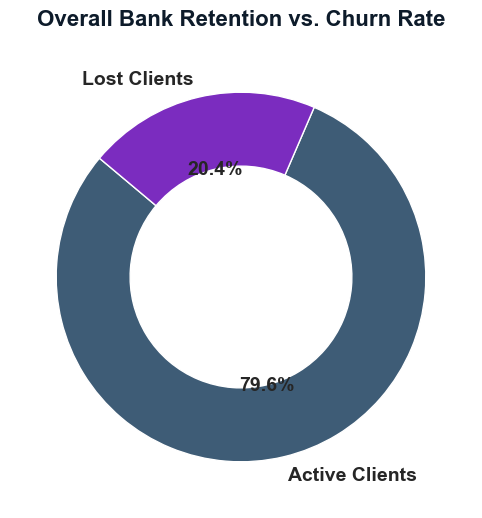

In [5]:

plt.figure(figsize=(8, 6), facecolor="#ffffff")
churn_counts = df['churn'].value_counts()
plt.pie(churn_counts, labels=["Active Clients", "Lost Clients"], autopct='%1.1f%%', startangle=140, 
        colors=["#3e5c76", "#7b2cbf"], wedgeprops=dict(width=0.4, edgecolor='w'), textprops={'fontsize': 14, 'weight': 'bold'})
plt.title("Overall Bank Retention vs. Churn Rate", fontsize=16, fontweight="bold", color="#0d1b2a", pad=15)
plt.show()

## Overall Customer Retention vs. Churn Analysis

The donut chart illustrates the baseline churn rate of the bank's portfolio. Out of the entire customer base, **20.4%** of the clients have exited the bank, while **79.6%** remain active.

* **Business Impact:** A 20.4% churn rate is significantly high for the banking industry, where retaining a customer is 5x cheaper than acquiring a new one. This baseline establishes an urgent need for targeted retention strategies.

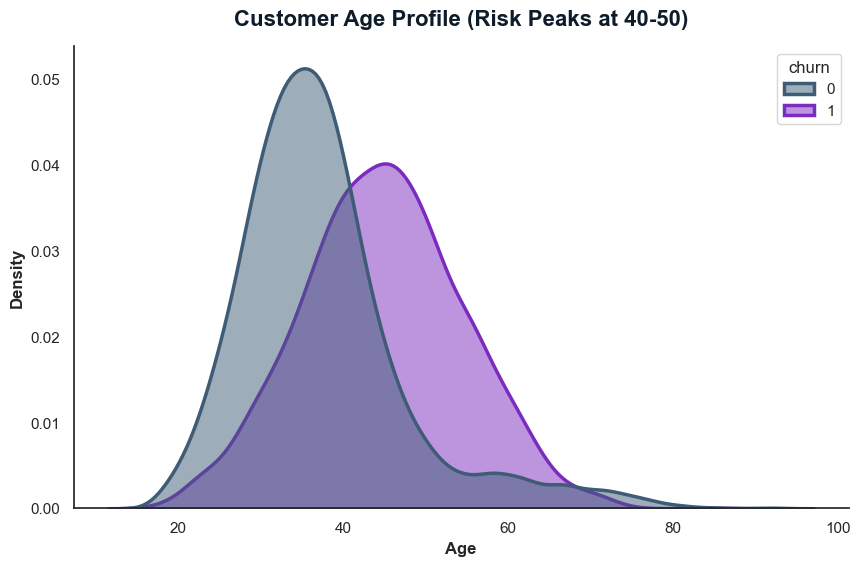

In [6]:
# Yaş ve Churn İlişkisi
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6), facecolor="#ffffff")
sns.kdeplot(data=df, x="age", hue="churn", fill=True, palette=["#3e5c76", "#7b2cbf"], alpha=0.5, common_norm=False, linewidth=2.5)
plt.title("Customer Age Profile (Risk Peaks at 40-50)", fontsize=16, fontweight="bold", color="#0d1b2a", pad=15)
plt.xlabel("Age", fontsize=12, fontweight="bold")
plt.ylabel("Density", fontsize=12, fontweight="bold")

# Çerçeve temizliği
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Customer Age Profile & Risk Distribution

The probability density chart reveals a critical structural pattern regarding the age distribution of departing clients.

* **The Core Discovery:** While the bank successfully retains its younger demographic (ages 20–35), customer churn drastically peaks between the **ages of 40 and 50**. 
* **Business Strategy:** Clients in the 40–50 age bracket generally hold higher account balances and utilize more financial products. Losing this segment represents a severe loss of premium capital. The bank must design customized loyalty programs and wealth management incentives tailored specifically for mid-aged and senior demographics.

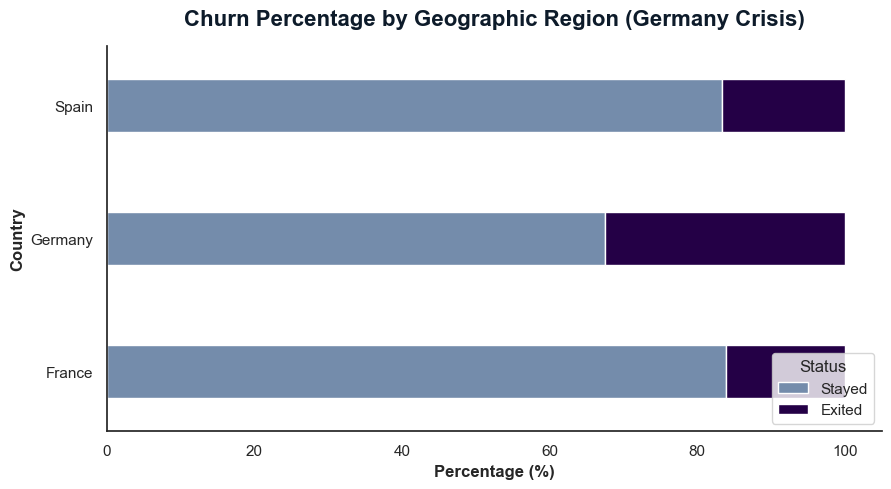

In [7]:
#  Ülkelere Göre Churn Analizi
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 5), facecolor="#ffffff")
country_churn = pd.crosstab(df['country'], df['churn'], normalize='index') * 100


country_churn.plot(kind='barh', stacked=True, color=["#748cab", "#240046"], width=0.4, ax=plt.gca())

plt.title("Churn Percentage by Geographic Region (Germany Crisis)", fontsize=16, fontweight="bold", color="#0d1b2a", pad=15)
plt.xlabel("Percentage (%)", fontsize=12, fontweight="bold")
plt.ylabel("Country", fontsize=12, fontweight="bold")
plt.legend(title="Status", labels=["Stayed", "Exited"], loc="lower right")

# Çerçeve temizliği
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Geographic Churn Analysis (The Germany Crisis)

Analyzing customer behavior across different regional markets highlights a significant operational anomaly in central Europe.

* **The Core Discovery:** While France and Spain showcase relatively healthy retention figures (with churn rates around 16%), **Germany suffers from a massive 32.4% churn rate**. Nearly one-third of German clients are leaving the bank.
* **Business Strategy:** This regional spike indicates severe localized issues in the German branch. It could be driven by aggressive local competitors, poor customer service localizations, or unfavorable fee structures. The bank must launch an immediate operational audit in Germany to identify root causes and deploy target-saving campaigns.

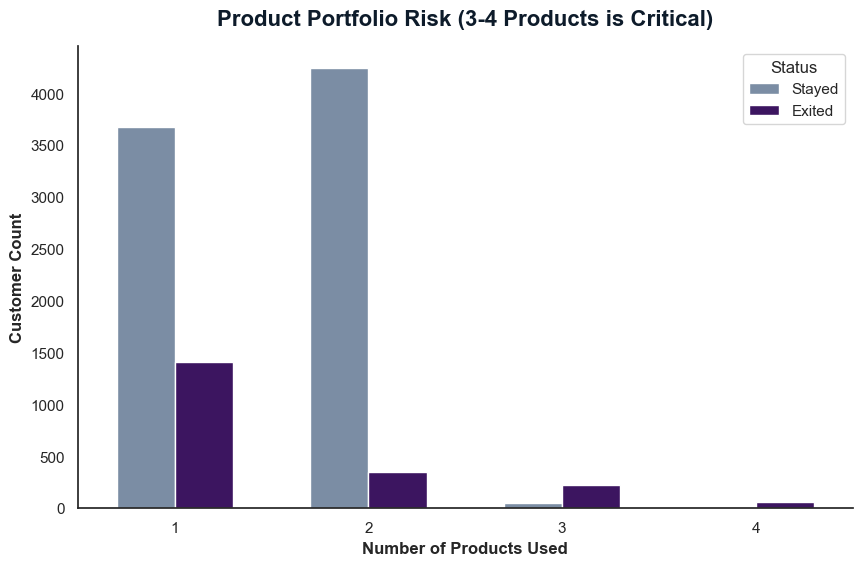

In [8]:
#Ürün Sayısı Analizi 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6), facecolor="#ffffff")

sns.countplot(data=df, x="products_number", hue="churn", palette=["#748cab", "#3c096c"], width=0.6)

plt.title("Product Portfolio Risk (3-4 Products is Critical)", fontsize=16, fontweight="bold", color="#0d1b2a", pad=15)
plt.xlabel("Number of Products Used", fontsize=12, fontweight="bold")
plt.ylabel("Customer Count", fontsize=12, fontweight="bold")
plt.legend(title="Status", labels=["Stayed", "Exited"], loc="upper right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Product Portfolio Risk & Cross-Selling Vulnerability

A deep dive into the correlation between the number of bank products a customer owns and their churn behavior reveals a counter-intuitive risk.

* **The Core Discovery:** While clients holding 1 or 2 products show stable retention, **clients with 3 or 4 products have a near-100% churn rate**. The data shows an absolute collapse in retention for multi-product users.
* **Business Strategy:** This is a classic indicator of "toxic cross-selling" or system exhaustion. Customers who are aggressively pushed to buy more products might be facing hidden fees, poor multi-product integration, or bad customer service. The product management team must immediately pause aggressive bundling campaigns and analyze why the bank's most active product users are completely dissatisfied.